In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from features import (feature_total_pages_count,
           total_number_of_sessions,
           time_last_used,
           last_level_of_each_customer,
           usage_metrices,
           num_status,
           exact_device_type,
           gender_feature_ont_hot,
           location_state_one_hot_encoded,
           member_since,
           num_different_songs,
           num_different_artists)
from pipeline import create_X_y_df

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

In [2]:
np.random.seed(42)

In [3]:
full_dataset_df = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [ ]:
full_dataset_df[(full_dataset_df["auth"] == "Cancelled") & (full_dataset_df["page"] != "Cancellation Confirmation")]


,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration


In [ ]:
df_ = full_dataset_df.copy(

)

In [29]:
df_["test_ts"] = pd.to_datetime(df_["ts"]).dt.second

In [30]:
df_.head()

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration,test_ts
0,200,M,Shlok,paid,Johnson,1749042,1538352001000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",278,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,524.32934,Ich mache einen Spiegel - Dream Part 4,Popol Vuh,2018-10-01 00:00:01,2018-08-08 13:22:21,38
992,200,M,Shlok,paid,Johnson,1749042,1538352525000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",279,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,178.02404,Monster (Album Version),Skillet,2018-10-01 00:08:45,2018-08-08 13:22:21,38
1360,200,M,Shlok,paid,Johnson,1749042,1538352703000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",280,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,232.61995,Seven Nation Army,The White Stripes,2018-10-01 00:11:43,2018-08-08 13:22:21,38
1825,200,M,Shlok,paid,Johnson,1749042,1538352935000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",281,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,265.50812,Under The Bridge (Album Version),Red Hot Chili Peppers,2018-10-01 00:15:35,2018-08-08 13:22:21,38
2366,200,M,Shlok,paid,Johnson,1749042,1538353200000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",282,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,471.69261,Circlesong 6,Bobby McFerrin,2018-10-01 00:20:00,2018-08-08 13:22:21,38


In [ ]:
full_dataset_df.sample(10)

# status -> Nelson
# gender -> Carl
# level -> Nelson
# ts -> Carl
# page -> Nelson
# location -> Carl
# itemInSession -> Nelson
# userAgent -> Carl
# method -> Nelson
# length -> Carl
# song -> Nelson
# artist -> Nelson
# time -> Carl
# registration -> Carl

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
9459601,200,F,Eva,paid,Jackson,1299911,1540827632000,Logged In,Add to Playlist,135691,"Houston-The Woodlands-Sugar Land, TX",29,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,NaN,None,None,2018-10-29 15:40:32,2018-05-17 21:46:04
2756398,200,M,Jacob,paid,Jones,1732411,1539106211000,Logged In,NextSong,9815,"San Jose-Sunnyvale-Santa Clara, CA",90,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",PUT,209.39710,Mad World,Tears For Fears,2018-10-09 17:30:11,2018-08-20 13:53:43
3016048,200,M,Thomas,paid,Sanchez,1004001,1539166541000,Logged In,NextSong,55263,"Hilo, HI",117,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,278.30812,Hot N Cold (Innerpartysystem Main),Katy Perry,2018-10-10 10:15:41,2018-09-11 16:14:44
10690987,200,F,Addilynn,paid,Jefferson,1878764,1541099190000,Logged In,NextSong,134338,"New York-Newark-Jersey City, NY-NJ-PA",51,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3...",PUT,229.61587,Let's Get It Started,Black Eyed Peas,2018-11-01 19:06:30,2018-09-10 17:35:56
5322542,200,F,Kaylynne,paid,Smith,1799501,1539762004000,Logged In,NextSong,86670,"Killeen-Temple, TX",472,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,249.20771,Between Two Lungs,Florence + The Machine,2018-10-17 07:40:04,2018-09-23 12:36:29
660105,200,M,Jonathan,free,Lopez,1662843,1538533235000,Logged In,Roll Advert,31878,"Portland-Vancouver-Hillsboro, OR-WA",4,Mozilla/5.0 (Windows NT 6.3; WOW64; Trident/7....,GET,NaN,None,None,2018-10-03 02:20:35,2018-06-26 07:26:49
15092937,200,M,Liam,paid,Brown,1236956,1542268245000,Logged In,NextSong,172464,"Lakeland-Winter Haven, FL",462,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_2...",PUT,299.59791,Hollywood,Jackie Greene,2018-11-15 07:50:45,2018-06-28 05:54:24
16226070,200,F,Emma,paid,Williams,1725162,1542612837000,Logged In,NextSong,196044,"Miami-Fort Lauderdale-West Palm Beach, FL",37,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",PUT,251.55873,I Couldn't Help It If I Tried,Dexy's Midnight Runners,2018-11-19 07:33:57,2018-07-28 12:25:29
11553605,200,M,Kohler,paid,Alvarado,1577946,1541356574000,Logged In,NextSong,154533,"Reno, NV",59,Mozilla/5.0 (Windows NT 6.1; rv:31.0) Gecko/20...,PUT,249.99138,Everlong,Foo Fighters,2018-11-04 18:36:14,2018-07-01 14:34:17
22043502,200,M,Carter,paid,Reeves,1127120,1540739712000,Logged In,NextSong,19501,"Dallas-Fort Worth-Arlington, TX",44,Mozilla/5.0 (Windows NT 6.3; WOW64; rv:31.0) G...,PUT,248.42404,Bling (Confession Of A King),The Killers,2018-10-28 15:15:12,2018-08-12 10:22:48


In [4]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = full_dataset_df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [5]:
def create_feature_engineered_df(df):
    feature_total_pages_count_df = feature_total_pages_count(df)
    total_number_of_sessions_df = total_number_of_sessions(df)
    time_last_used_df = time_last_used(df)
    last_level_of_each_customer_df = last_level_of_each_customer(df)
    usage_metrices_df = usage_metrices(df)
    num_status_df = num_status(df)
    device_type_df = exact_device_type(df)
    gender_feature_ont_hot_df = gender_feature_ont_hot(df)
    location_state_one_hot_encoded_df = location_state_one_hot_encoded(df)
    member_since_df = member_since(df)
    num_different_songs_df = num_different_songs(df)
    num_different_artists_df = num_different_artists(df)


    df = feature_total_pages_count_df.merge(total_number_of_sessions_df,
                                            on = "userId")

    df = df.merge(time_last_used_df, on = "userId")
    df = df.merge(last_level_of_each_customer_df, on = "userId")
    df = df.merge(usage_metrices_df, on = "userId")
    df = df.merge(num_status_df, on = "userId")
    df = df.merge(device_type_df, on = "userId")
    df = df.merge(gender_feature_ont_hot_df, on = "userId")
    df = df.merge(location_state_one_hot_encoded_df, on = "userId")
    df = df.merge(member_since_df, on = "userId")
    df = df.merge(num_different_songs_df, on = "userId")
    df = df.merge(num_different_artists_df, on = "userId")

    return df


df_X_features = create_feature_engineered_df(df_X)

/Users/aaron/Desktop/1_Studium/1_Master/1_Polytechnique/1_Courses/4_Python_for_Data_Science/2_Kaggle_Challenge/kaggle_challenge/src/features/device_used.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b.loc[:, "val"] = np.ones(len(df_b))


In [6]:
df_X_features

,userId,About,Add Friend,Add to Playlist,Downgrade,Error,Help,Home,Logout,NextSong,...,UT,VA,VT,WA,WI,WV,WY,member_since,num_different_songs,num_different_artists
0,1000035,2.0,14.0,18.0,2.0,0.0,3.0,33.0,11.0,745.0,...,0,0,0,0,0,0,0,53,704,600
1,1000103,0.0,0.0,1.0,1.0,0.0,0.0,5.0,2.0,52.0,...,0,0,0,0,0,0,0,43,53,52
2,1000164,1.0,5.0,10.0,0.0,0.0,2.0,15.0,3.0,368.0,...,0,0,0,0,0,0,0,84,351,320
3,1000168,0.0,10.0,10.0,1.0,0.0,2.0,18.0,6.0,351.0,...,0,0,0,0,0,0,0,88,343,312
4,1000182,0.0,4.0,11.0,5.0,0.0,2.0,11.0,5.0,289.0,...,0,0,0,0,1,0,0,124,283,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15428,1999241,2.0,5.0,4.0,2.0,0.0,1.0,13.0,5.0,250.0,...,0,0,0,0,0,0,0,38,244,232
15429,1999382,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,32.0,...,0,0,0,0,0,0,0,37,33,33
15430,1999781,5.0,33.0,53.0,12.0,3.0,12.0,78.0,27.0,2073.0,...,0,0,0,0,0,0,0,65,1819,1377
15431,1999848,1.0,15.0,15.0,0.0,1.0,5.0,29.0,10.0,419.0,...,0,0,0,0,0,0,0,65,399,362


In [7]:
df_X_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15433 entries, 0 to 15432
Columns: 106 entries, userId to num_different_artists
dtypes: bool(1), float64(47), int64(56), object(2)
memory usage: 12.4+ MB


In [8]:
df_X_features = df_X_features.sort_values("userId")
df_y = df_y.sort_values("userId")

In [9]:
df_X_features.columns

Index(['userId', 'About', 'Add Friend', 'Add to Playlist', 'Downgrade',
       'Error', 'Help', 'Home', 'Logout', 'NextSong',
       ...
       'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY', 'member_since',
       'num_different_songs', 'num_different_artists'],
      dtype='object', length=106)

In [10]:
df_y.columns

Index(['userId', 'Cancellation Confirmation'], dtype='object')

In [11]:
"""
columns_X = ['About', 'Add Friend', 'Add to Playlist',
              'Downgrade', 'Error', 'Help', 'Home',
       'Logout', 'NextSong', 'Roll Advert', 'Save Settings', 'Settings',
       'Submit Downgrade', 'Submit Upgrade', 'Thumbs Down', 'Thumbs Up',
       'Upgrade', 'total_number_of_sessions', 'time_not_used',
       'mean_tps_minutes', 'mean_tbs_minutes', 'median_tps_minutes',
       'median_tbs_minutes', 'level', 'exact_device']
"""

columns_X = df_X_features.columns.drop(["userId"])


columns_y = "Cancellation Confirmation"

In [12]:
num_cols = df_X_features[columns_X].select_dtypes(include=["int64", "float64"]).\
    columns.tolist()


categorical_columns = df_X_features[columns_X].select_dtypes(include=["object"]).\
    columns.tolist()

preprocesseor_lr=ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), num_cols),
        ("categorical", OneHotEncoder(), categorical_columns),
    ]
)

one_hot_dense_preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore",
                                 sparse_output=False), categorical_columns),
    ],
    remainder="passthrough"
)

model_lr = Pipeline([
    ("prepocesseor", preprocesseor_lr),
    ("model", LogisticRegression(max_iter=10000))#, class_weight={0:1, 1:10}))
])


model_hgbc = Pipeline([
    ("prepocesseor", one_hot_dense_preprocessor),
    ("model", HistGradientBoostingClassifier(max_depth=50))
])

In [13]:
# Remove identifier column before scaling/modeling
X = df_X_features[columns_X]
y = df_y[columns_y]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [14]:
y_train

175      0
7522     0
7013     0
11983    0
10455    0
        ..
13725    0
1595     0
1923     0
2276     0
14056    0
Name: Cancellation Confirmation, Length: 11574, dtype: int8

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3678
           1       0.00      0.00      0.00       181

    accuracy                           0.95      3859
   macro avg       0.48      0.50      0.49      3859
weighted avg       0.91      0.95      0.93      3859



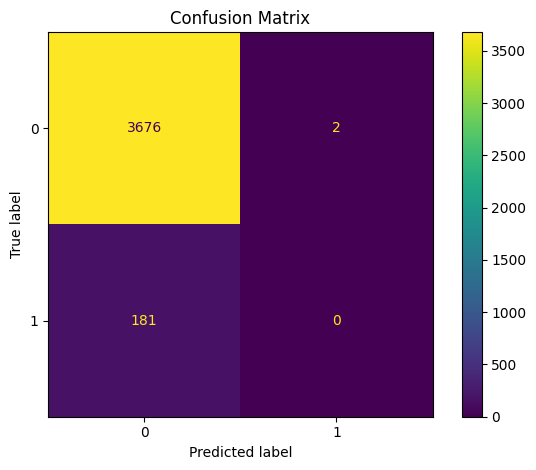

{'fit_time': array([0.45145702, 0.43094206, 0.40500283, 0.49249816, 0.70226216]),
 'score_time': array([0.03601694, 0.03390002, 0.0345273 , 0.03361988, 0.03803587]),
 'test_score': array([0.95238095, 0.95205701, 0.95140914, 0.95139339, 0.95171743]),
 'train_score': array([0.95561315, 0.95439819, 0.95650413, 0.95828946, 0.96574067])}

In [15]:
model_hgbc.fit(X_train, y_train)
pred = model_hgbc.predict(X_test)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cross_validate(model_hgbc, X, y, return_train_score=True)


#https://scikit-learn.org/stable/modules/ensemble.html#interpretation-with-feature-importance

[[3670    8]
 [ 179    2]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3678
           1       0.20      0.01      0.02       181

    accuracy                           0.95      3859
   macro avg       0.58      0.50      0.50      3859
weighted avg       0.92      0.95      0.93      3859



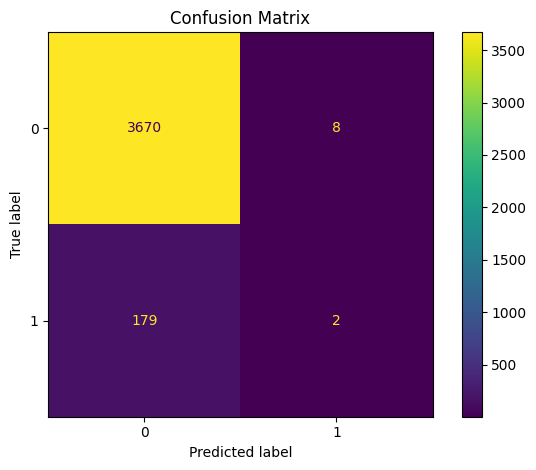

In [16]:


# 2) Preprocess: impute + one-hot for categoricals, impute for numerics
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # use sparse output by default
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_columns),
        ("num", numeric_pipeline, num_cols),
    ],
    remainder="passthrough"
)

# 3) Model
"""xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"  # avoids warning in many setups
)
"""

n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
spw = n_neg / max(n_pos, 1)

#xgb = XGBClassifier(scale_pos_weight = spw, eval_metric="aucpr")
xgb = XGBClassifier()

# 4) Full pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb)
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

# numeric matrix
cm = confusion_matrix(y_test, pred)
print(cm)

print(classification_report(y_test, pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [17]:
cross_validate(clf, X, y, return_train_score=True)

{'fit_time': array([0.39615107, 0.40061378, 0.39246416, 0.38478899, 0.41431808]),
 'score_time': array([0.01081705, 0.01280904, 0.01079822, 0.01194215, 0.0113821 ]),
 'test_score': array([0.95140914, 0.95011338, 0.95011338, 0.9507453 , 0.9507453 ]),
 'train_score': array([0.99781306, 0.99919002, 0.99748907, 0.99870414, 0.9981372 ])}

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

scores = cross_validate(
    clf, X, y,
    cv=cv,
    scoring=["accuracy", "balanced_accuracy", "f1", "roc_auc"],
    return_train_score=True
)
scores

{'fit_time': array([0.39839411, 0.38926601, 0.38807297, 0.3943429 , 0.39145803]),
 'score_time': array([0.02669287, 0.02529287, 0.02860498, 0.0289731 , 0.02608109]),
 'test_accuracy': array([0.94914156, 0.95076126, 0.95011338, 0.95204148, 0.95042126]),
 'train_accuracy': array([0.99919002, 0.99708408, 0.99781306, 0.99838017, 0.9991091 ]),
 'test_balanced_accuracy': array([0.5047619 , 0.50884354, 0.50204082, 0.52244852, 0.50867295]),
 'train_balanced_accuracy': array([0.9914966 , 0.96938776, 0.97704082, 0.9829932 , 0.99064626]),
 'test_f1': array([0.02484472, 0.03797468, 0.01282051, 0.08641975, 0.03773585]),
 'train_f1': array([0.99142367, 0.96842105, 0.97650131, 0.98269896, 0.99055794]),
 'test_roc_auc': array([0.68030682, 0.69325744, 0.68718127, 0.70652242, 0.70718672]),
 'train_roc_auc': array([1.        , 0.99999913, 0.99999653, 1.        , 1.        ])}

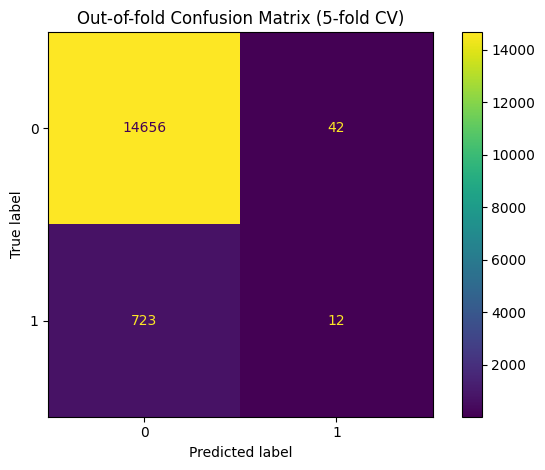

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

oof_pred = cross_val_predict(clf, X, y, cv=cv, method="predict")

ConfusionMatrixDisplay.from_predictions(y, oof_pred, values_format="d")
plt.title("Out-of-fold Confusion Matrix (5-fold CV)")
plt.tight_layout()
plt.show()